# 安裝與匯入資料

In [2]:
# 安裝件
!pip install git+https://github.com/qubvel/segmentation_models.pytorch
!pip install ipywidgets


  Cloning https://github.com/qubvel/segmentation_models.pytorch to /private/var/folders/y2/ky6z7grj7d7bxn4zzvqx738h0000gn/T/pip-req-build-kd5qq4i7
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /private/var/folders/y2/ky6z7grj7d7bxn4zzvqx738h0000gn/T/pip-req-build-kd5qq4i7
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit f47671d24076ef13b4a85090fdf8749a5a969aa6
  Installing build dependencies ... one
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 4.5 MB/s eta 0:00:004.4 MB/s eta 0:00:01
  Created wheel for segmentation_models_pytorch: filename=segmentation_models_pytorch-0.5.1.dev0-py3-none-any.whl size=157855 sha256=ba85d86faf36335b1ceac2544629203ede49f53e5e3deefe2655e892b842026b
  Stored in directory: /private/var/folders/y2/ky6z7grj7d7bxn4zzvqx738h0000gn/T/pip-ephem-wheel-cache-ihl8ztcp/wheels/25

In [3]:
# 匯入常用套件與模組
import torch
import numpy as np
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.utils import losses
from torch import nn

print("🚀 所有套件成功載入！PyTorch 版本：", torch.__version__)

🚀 所有套件成功載入！PyTorch 版本： 2.11.0


In [4]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import json
import random
import torch

# Data Loader Setup ＆ Data Preprocessing

In [5]:
DATA_DIR_train = 'rib_dataset/train'
DATA_DIR_test = 'rib_dataset/test'

# 如果訓練資料集資料夾不存在，則下載資料
if not os.path.exists(DATA_DIR_train):
    print('Loading data...')
    print('Done!')

In [6]:
# 訓練資料集的影像資料
x_train_dir = 'rib_dataset/train/img'
# 訓練資料集的標註資料
y_train_dir = 'rib_dataset/train/mask'

# 測試資料集的影像資料
x_test_dir = 'rib_dataset/test/img'
# 測試資料集的標註資料
y_test_dir = 'rib_dataset/test/mask'

In [7]:
# 用於資料視覺化的輔助函數
def visualize(**images):
    """將多張圖片繪製在同一排中。"""
    n = len(images)  # 計算傳入的圖片數量
    plt.figure(figsize=(16, 16))  # 設定畫布大小（16x16 英吋）
    
    # 迭代每張圖片，並將其顯示在畫布上
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)  # 在一行中創建子圖，總共 n 個子圖
        plt.xticks([]) 
        plt.yticks([])  
        plt.title(' '.join(name.split('_')).title())  
        plt.imshow(image)  # 顯示圖像
    
    plt.show()  


In [8]:
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import torch.nn.functional as F

In [10]:
# 定義所有的類別名稱（例如：'rib' 和 'bg'）
CLASSES = ['rib', 'bg']

# 將 CLASSES 複製到 classes 變數中
classes = CLASSES

# 每個類別名稱轉換為其對應的索引值
class_values = [CLASSES.index(cls.lower()) for cls in classes]

# 輸出 class_values，顯示每個類別的索引
print(class_values)


[0, 1]


In [50]:
import os
import cv2
import numpy as np
from torch.utils.data import Dataset as BaseDataset

class Dataset(BaseDataset):
    CLASSES = ['rib', 'bg']

    def __init__(self,
                 images_dir=None,
                 masks_dir=None,
                 images_fps=None,
                 masks_fps=None,
                 classes=None,
                 augmentation=None,
                 preprocessing=None):
        
        if images_fps is not None and masks_fps is not None:
            self.images_fps = images_fps
            self.masks_fps = masks_fps
        elif images_dir is not None and masks_dir is not None:
            # 過濾 解決.ipynb_checkpoints問題
            valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
            
            # 使用 os.path.isfile 確保只抓檔案，排除資料夾
            self.ids = sorted([
                f for f in os.listdir(images_dir) 
                if os.path.isfile(os.path.join(images_dir, f)) 
                and f.lower().endswith(valid_extensions) 
                and not f.startswith('.')
            ])
            
            self.images_fps = [os.path.join(images_dir, fname) for fname in self.ids]
            self.masks_fps = [
                os.path.join(masks_dir, os.path.splitext(fname)[0] + '.png') 
                for fname in self.ids
            ]
            
            print(f"成功過濾！目前資料集共有 {len(self.ids)} 張影像。")
            
        else:
            raise ValueError("Either images_dir + masks_dir or images_fps + masks_fps must be provided.")

        self.class_values = [self.CLASSES.index(cls.lower()) for cls in classes]
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __getitem__(self, i):
        image_path = self.images_fps[i]
        mask_path = self.masks_fps[i]

        # 讀取影像
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None: raise FileNotFoundError(f"無法讀取影像: {image_path}")
        image = cv2.resize(image, (512, 512), interpolation=cv2.INTER_LANCZOS4)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) # 直接轉換比 stack 更快

        # 讀取遮罩
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None: raise FileNotFoundError(f"無法讀取遮罩: {mask_path}")
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype('float32')

        # 類別處理
        masks = []
        if 0 in self.class_values: masks.append(mask)      # 'rib'
        if 1 in self.class_values: masks.append(1 - mask)  # 'bg'
        if not masks: masks = [mask]
            
        mask = np.stack(masks, axis=-1)

        # 同步擴增與前處理
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return image, mask

    def __len__(self):
        return len(self.images_fps)

In [51]:
print(len(glob.glob(y_test_dir+'/*')), len(glob.glob(x_test_dir+'/*')))

49 49


In [52]:
import albumentations as albu

def get_training_augmentation():
    """建立訓練資料的擴增操作
    這個函數定義了一組影像的資料擴增操作，
    這些操作會隨機地應用於影像，用來增加資料多樣性並防止過擬合。

    """
    train_transform = [
        # 水平翻轉影像，50%機率
        albu.HorizontalFlip(p=0.5),

        # 增強影像的銳利度，50%機率
        albu.Sharpen(p=0.5),

        # 隨機改變影像的亮度和對比度，40%機率
        albu.RandomBrightnessContrast(p=0.4),

        # 隨機裁剪影像為 480x480，50%機率
        albu.Crop(x_min=0, y_min=0, x_max=480, y_max=480, p=0.5),

        # 如果影像小於 512x512，則填充至 512x512
        albu.PadIfNeeded(512, 512)
    ]
    return albu.Compose(train_transform)

def to_tensor(x, **kwargs):
    """將影像或遮罩轉換為 Tensor 格式並將通道維度移到前面
    
    Args:
        x: 影像或遮罩數據，應該是 HWC 格式
        
    Returns:
        numpy.ndarray: 轉換為 CHW 格式的影像或遮罩數據
    """
    # 將影像從 HWC 轉換為 CHW 並將數據類型轉換為 float32
    return x.transpose(2, 0, 1).astype('float32')

def get_preprocessing(preprocessing_fn):
    """資料前處理

    這個函數會根據給定的 preprocessing_fn 來處理影像資料，
    並將影像和遮罩轉換為 PyTorch 所需的 Tensor 格式。

    Args:
        preprocessing_fn (callable): 資料正規化函數（通常用於每個預訓練模型）
        
    Returns:
        albu.Compose: 由資料正規化和轉換為 Tensor 的操作組成的變換
    """
    _transform = [
        # 應用給定的資料正規化函數
        albu.Lambda(image=preprocessing_fn),
        
        # 將影像和遮罩轉換為 Tensor 格式
        albu.Lambda(image=to_tensor, mask=to_tensor),
    ]
    return albu.Compose(_transform)


成功過濾！目前資料集共有 196 張影像。


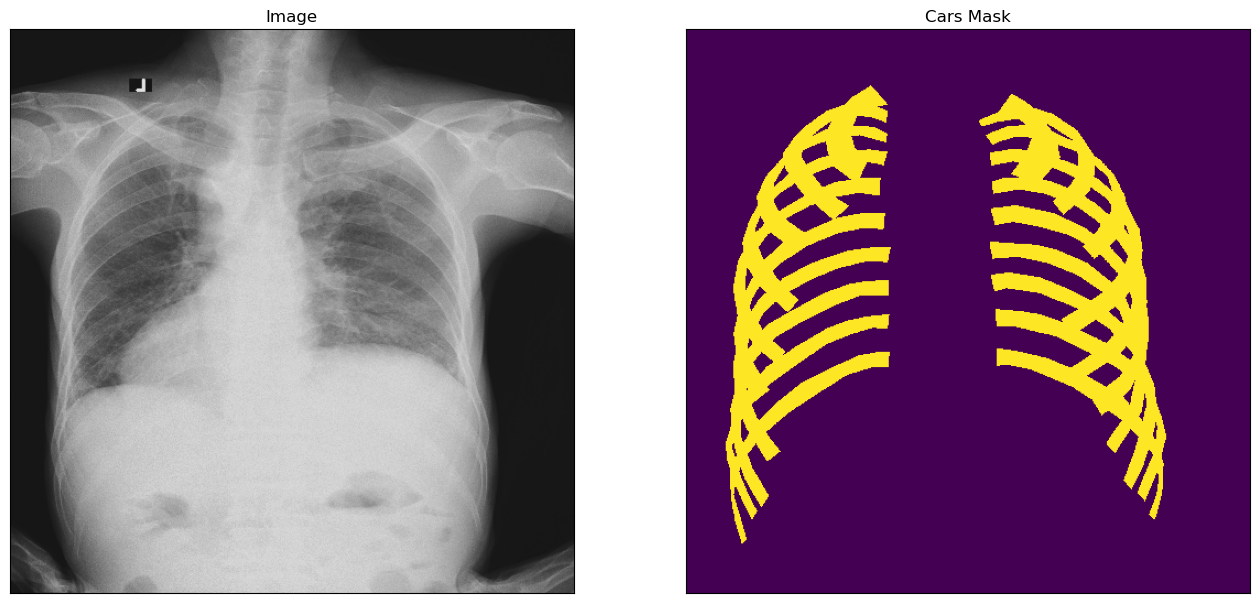

In [53]:
dataset = Dataset(x_train_dir, y_train_dir, classes= ['rib'], augmentation=get_training_augmentation())
image, mask = dataset[0]
# 顯示圖片與遮罩
visualize(
    image=image / 255,  # 正規化影像
    cars_mask=mask.squeeze(), 
)

## Create model and train

In [54]:
import torch
import numpy as np
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.utils import losses
from torch import nn

In [55]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

#編碼器名稱與預訓練權重
ENCODER = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'

#輸出類別與激活函數
CLASSES = ['rib', 'bg']
ACTIVATION = 'softmax2d'
DEVICE = 'cuda'

# 使用預訓練編碼器創建 U-Net 模型
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    classes=len(CLASSES),
    activation=ACTIVATION,
)

# 凍結編碼器的前幾層
for param in model.encoder.parameters():
    param.requires_grad = False

# 解凍 layer1 層
for param in model.encoder.layer1.parameters():
    param.requires_grad = True

# 解凍 layer2 層
for param in model.encoder.layer2.parameters():
    param.requires_grad = True

# 解凍 layer3 層
for param in model.encoder.layer3.parameters():
    param.requires_grad = True

# 解凍 layer4 層
for param in model.encoder.layer4.parameters():
    param.requires_grad = True

# 使用預訓練編碼器的預處理函數來處理影像
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)

# 檢查哪些層會被訓練
for name, param in model.named_parameters():
    print(f"{name}: {param.requires_grad}")

encoder.conv1.weight: False
encoder.bn1.weight: False
encoder.bn1.bias: False
encoder.layer1.0.conv1.weight: True
encoder.layer1.0.bn1.weight: True
encoder.layer1.0.bn1.bias: True
encoder.layer1.0.conv2.weight: True
encoder.layer1.0.bn2.weight: True
encoder.layer1.0.bn2.bias: True
encoder.layer1.0.conv3.weight: True
encoder.layer1.0.bn3.weight: True
encoder.layer1.0.bn3.bias: True
encoder.layer1.0.downsample.0.weight: True
encoder.layer1.0.downsample.1.weight: True
encoder.layer1.0.downsample.1.bias: True
encoder.layer1.1.conv1.weight: True
encoder.layer1.1.bn1.weight: True
encoder.layer1.1.bn1.bias: True
encoder.layer1.1.conv2.weight: True
encoder.layer1.1.bn2.weight: True
encoder.layer1.1.bn2.bias: True
encoder.layer1.1.conv3.weight: True
encoder.layer1.1.bn3.weight: True
encoder.layer1.1.bn3.bias: True
encoder.layer1.2.conv1.weight: True
encoder.layer1.2.bn1.weight: True
encoder.layer1.2.bn1.bias: True
encoder.layer1.2.conv2.weight: True
encoder.layer1.2.bn2.weight: True
encoder.lay

In [61]:
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 過濾檔案 排除所有以 "." 開頭的隱藏檔 (如 .ipynb_checkpoints)
valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
all_fnames = sorted([
    f for f in os.listdir(x_train_dir) 
    if f.lower().endswith(valid_extensions) and not f.startswith('.')
])

# 根據過濾後的名單建立路徑
all_image_paths = [os.path.join(x_train_dir, fname) for fname in all_fnames]
all_mask_paths = [
    os.path.join(y_train_dir, os.path.splitext(fname)[0] + '.png') 
    for fname in all_fnames
]

print(f"成功過濾！共找到 {len(all_image_paths)} 張有效影像，準備進行切分。")

# 自動切分資料集 (80/20)
train_images, valid_images, train_masks, valid_masks = train_test_split(
    all_image_paths, 
    all_mask_paths, 
    test_size=0.2, 
    random_state=42
)

# Dataset實體
train_dataset = Dataset(
    images_fps=train_images,
    masks_fps=train_masks,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn),
    classes=CLASSES,
)

valid_dataset = Dataset(
    images_fps=valid_images,
    masks_fps=valid_masks,
    preprocessing=get_preprocessing(preprocessing_fn),
    classes=CLASSES,
)

# 訓練集：開啟資料擴增 
train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False
)
# 驗證集：不使用擴增，僅執行正規化等前處理
valid_loader = DataLoader(
    valid_dataset, 
    batch_size=4, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False
)

print(f"DataLoader 準備就緒。訓練集 Batch 數: {len(train_loader)}")

成功過濾！共找到 196 張有效影像，準備進行切分。
DataLoader 準備就緒。訓練集 Batch 數: 39


In [62]:
# 使用Dice Loss作為損失函數
loss = losses.DiceLoss()
metrics = [
    smp.utils.metrics.IoU(threshold=0.5),
]
# 使用IoU作為評估指標
optimizer = torch.optim.Adam([
    dict(params=model.parameters(), lr=0.0001),
])
# 使用ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

In [63]:
import torch

# GPU設定
if torch.backends.mps.is_available():
    DEVICE = "mps"
    print("使用 GPU (MPS) 加速")
else:
    DEVICE = "cpu"
    print("使用 CPU 運算")

# 訓練epoch物件
train_epoch = smp.utils.train.TrainEpoch(
    model,                    # 傳入的模型
    loss=loss,                # 損失函數
    metrics=metrics,          # 評估指標
    optimizer=optimizer,      # 優化器
    device=DEVICE,            # 設定運行設備
    verbose=True,             # 是否顯示訓練過程中的詳細資訊
)

# 驗證epoch物件
valid_epoch = smp.utils.train.ValidEpoch(
    model,                   
    loss=loss,              
    metrics=metrics,          
    device=DEVICE,           
    verbose=True,             
)


使用 GPU (MPS) 加速


In [64]:
import os

# 創建資料夾路徑
path = './model/'

# 使用 os.makedirs() 創建資料夾
os.makedirs(path, exist_ok=True)

In [65]:
# 初始化變數，用來保存每一個 epoch 中的訓練與驗證損失和 IoU 評分
max_score = 0  #最佳驗證 IoU
train_loss_list = []  # 保存每個 epoch 訓練損失
train_iou_score_list = []  #保存每epoch訓 IoU評分
valid_loss_list = []  #保存每個 epoch 驗證損失
valid_iou_score_list = []  #保存每個 epoch驗證IoU評分

# 執行訓練和驗證
for i in range(30):

    # 顯示當前的 epoch數
    print('\nEpoch: {}'.format(i))
    
    # 執行訓練過程
    train_logs = train_epoch.run(train_loader)  # 訓練一個 epoch
    train_loss_list.append(train_logs['dice_loss'])  # 保存訓練損失
    train_iou_score_list.append(train_logs['iou_score'])  # 保存訓練 IoU 評分
    print(train_logs['iou_score'])  # 顯示訓練集的 IoU 評分

    # 執行驗證過程
    valid_logs = valid_epoch.run(valid_loader)  # 驗證一個 epoch
    valid_loss_list.append(valid_logs['dice_loss'])  # 保存驗證損失
    valid_iou_score_list.append(valid_logs['iou_score'])  # 保存驗證 IoU 評分
    print(valid_logs['iou_score'])  # 顯示驗證集的 IoU 評分

    # 如果當前驗證 IoU 優於之前的最佳分數，則保存模型
    if max_score < valid_logs['iou_score']:  # 判斷是否達到更好的驗證 IoU
        max_score = valid_logs['iou_score']  # 更新最佳分數
        torch.save(model, path+'/best_model_unet_resnet50.pth')  # 保存當前最佳模型
        print('Model saved!')  # 顯示模型儲存




Epoch: 0
train: 100%|█| 39/39 [00:44<00:00,  1.14s/it, dice_loss - 0.2059, iou_score - 0.
0.7348404
valid: 100%|█| 10/10 [00:06<00:00,  1.64it/s, dice_loss - 0.1504, iou_score - 0.
0.8077944
Model saved!

Epoch: 1
train: 100%|█| 39/39 [00:43<00:00,  1.11s/it, dice_loss - 0.1581, iou_score - 0.
0.77812845
valid: 100%|█| 10/10 [00:06<00:00,  1.66it/s, dice_loss - 0.1126, iou_score - 0.
0.8434548
Model saved!

Epoch: 2
train: 100%|█| 39/39 [00:43<00:00,  1.10s/it, dice_loss - 0.1351, iou_score - 0.
0.7993551
valid: 100%|█| 10/10 [00:06<00:00,  1.66it/s, dice_loss - 0.1007, iou_score - 0.
0.85403717
Model saved!

Epoch: 3
train: 100%|█| 39/39 [00:43<00:00,  1.11s/it, dice_loss - 0.1154, iou_score - 0.
0.8234795
valid: 100%|█| 10/10 [00:06<00:00,  1.65it/s, dice_loss - 0.0887, iou_score - 0.
0.86456424
Model saved!

Epoch: 4
train: 100%|█| 39/39 [00:42<00:00,  1.10s/it, dice_loss - 0.1131, iou_score - 0.
0.81959534
valid: 100%|█| 10/10 [00:06<00:00,  1.65it/s, dice_loss - 0.08249, iou_scor

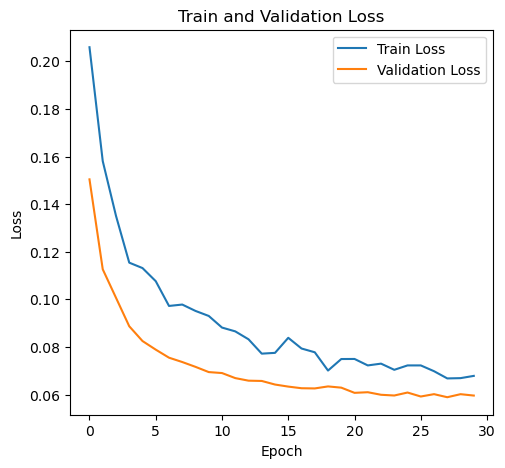

In [66]:
# 完成所有 epoch 訓練後，進行結果的視覺化
# 訓練損失與驗證損失曲線
plt.figure(figsize=(12, 5))

# 訓練和驗證損失
plt.subplot(1, 2, 1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(valid_loss_list, label='Validation Loss')
plt.title('Train and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

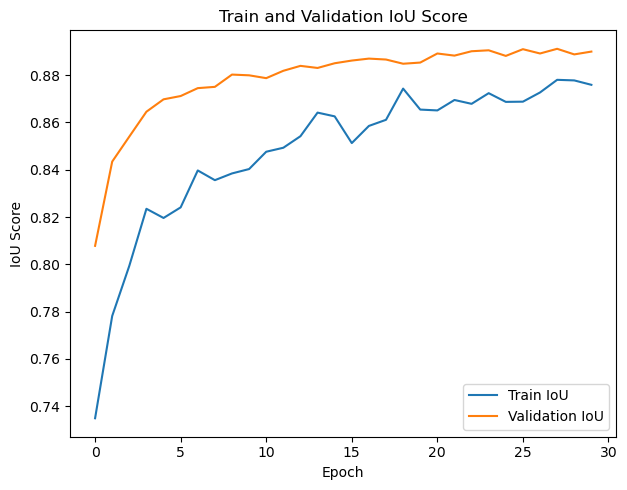

In [89]:
# 訓練和驗證 IoU 分數
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(train_iou_score_list, label='Train IoU')
plt.plot(valid_iou_score_list, label='Validation IoU')
plt.title('Train and Validation IoU Score')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()

plt.tight_layout()
plt.show()

In [70]:
import torch
import segmentation_models_pytorch as smp
path = 'model'

# 使用 weights_only=False 載入整個模型
model = torch.load(path + '/best_model_unet_resnet50.pth', map_location=device, weights_only=False)

# 將模型移動到指定設備
model.to(device)

# 設置模型為評估模式
model.eval()


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [71]:
from torch.utils.data import Dataset as BaseDataset

class TestDataset(BaseDataset):
    """
    用於影像分割的測試資料集
    """

    def __init__(self,
                 images_fps,
                 masks_fps,
                 classes,
                 augmentation=None,
                 preprocessing=None):
        """
        初始化資料集類別
        """
        self.images_fps = images_fps  # 影像檔案
        self.masks_fps = masks_fps    # 遮罩檔案
        # 根據類別名稱列表，將每個類別轉換為其對應的索引
        self.class_values = [Dataset.CLASSES.index(cls.lower()) for cls in classes]
        self.augmentation = augmentation  # 資料擴增
        self.preprocessing = preprocessing  # 前處理

    def __getitem__(self, i):
        """
        取得索引 i 對應的影像和遮罩資料

        參數：
            i: 影像和遮罩的索引
        
        返回：
            original_image_for_plot: 用於顯示的原圖影像，形狀為 (H, W)
            image: 處理過的影像，形狀為 (H, W, 3)，可以送入模型
            mask: 處理過的遮罩，形狀為 (H, W, N)，N為類別數
        """
        # 取得影像和遮罩的路徑
        image_path = self.images_fps[i]
        mask_path = self.masks_fps[i]

        # 讀原圖（灰階）
        original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if original_image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        original_image = cv2.resize(original_image, (512, 512), interpolation=cv2.INTER_LANCZOS4)

        # 顯示用：將原圖複製以便顯示，shape 為 (H, W)
        original_image_for_plot = original_image.copy()

        # 模型使用：將灰階影像轉為 RGB 格式，形狀變為 (H, W, 3)
        image = np.stack([original_image] * 3, axis=-1)

        # 讀取遮罩（灰階）
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Failed to load mask: {mask_path}")
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype('float32')  # 將遮罩二值化

        # 根據類別數量生成相應的遮罩
        masks = []
        if 0 in self.class_values:
            masks.append(mask)  # 如果需要 'rib' 類別
        if 1 in self.class_values:
            masks.append(1 - mask)  # 如果需要 'bg' 類別
        mask = np.stack(masks, axis=-1)  # 合併所有的遮罩類別，shape 為 (H, W, N)

        # 執料擴增
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        # 前處理
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']

        return original_image_for_plot, image, mask  # 返回原圖、處理後影像和遮罩

    def __len__(self):
        """返回資料集中的樣本數量"""
        return len(self.images_fps)


In [73]:
import os
from torch.utils.data import DataLoader

# 測試影像檔案
test_image_paths = sorted([os.path.join('rib_dataset/test/img', fname) for fname in os.listdir('rib_dataset/test/img')])

# 測試遮罩檔案
test_mask_paths = sorted([os.path.join('rib_dataset/test/mask', fname) for fname in os.listdir('rib_dataset/test/img')])

# 創建測試資料集
test_dataset = TestDataset(
    images_fps=test_image_paths,  # 影像檔案
    masks_fps=test_mask_paths,    # 遮罩檔案
    preprocessing=get_preprocessing(preprocessing_fn),  # 前處理方法
    classes=CLASSES,  # 類別名稱（例如 'rib' 和 'bg'）
)

# DataLoader 
#huffle=False 資料順序不被隨機打亂
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)


使用 GPU (MPS) 進行推論


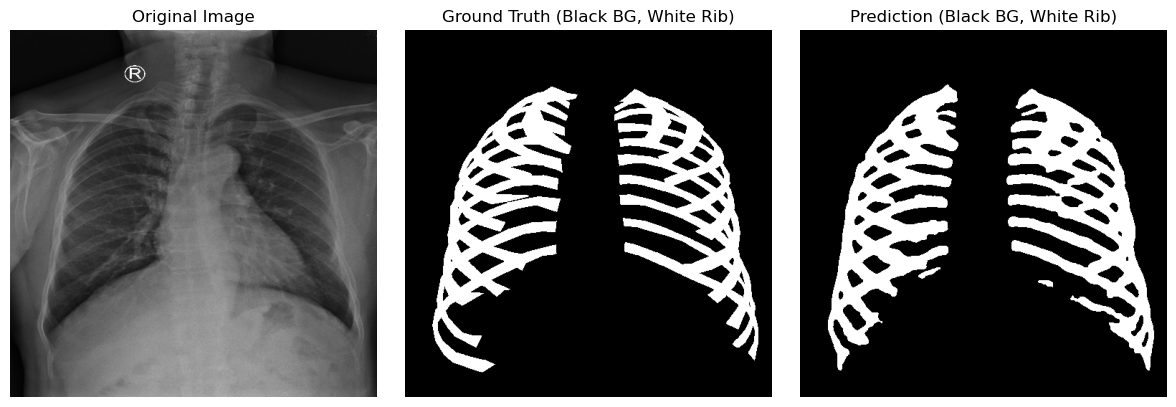

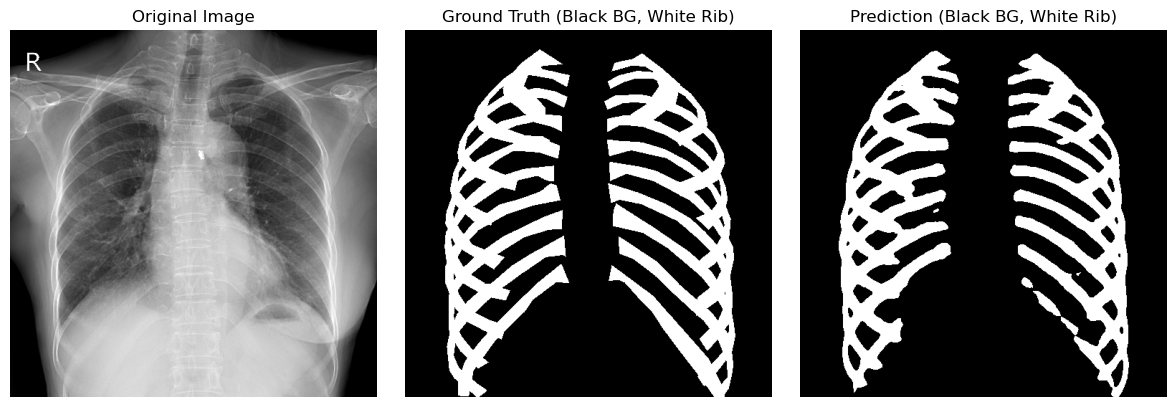

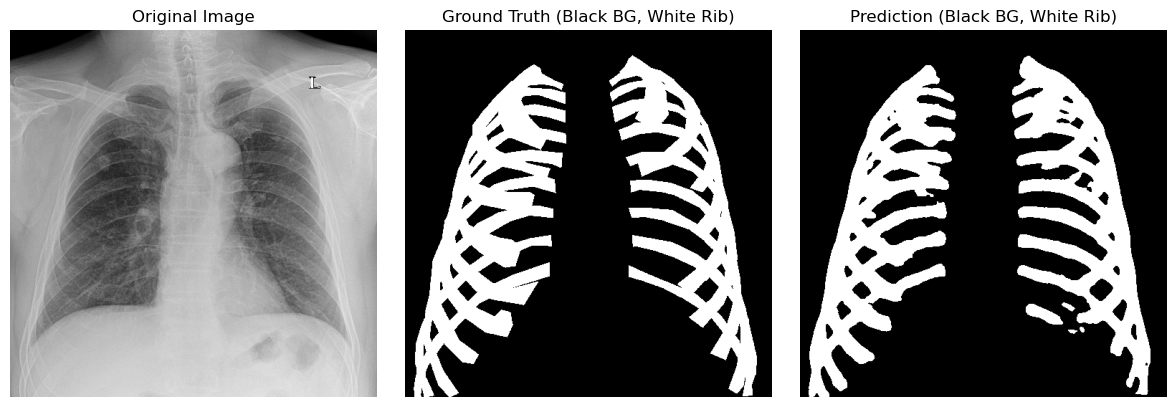

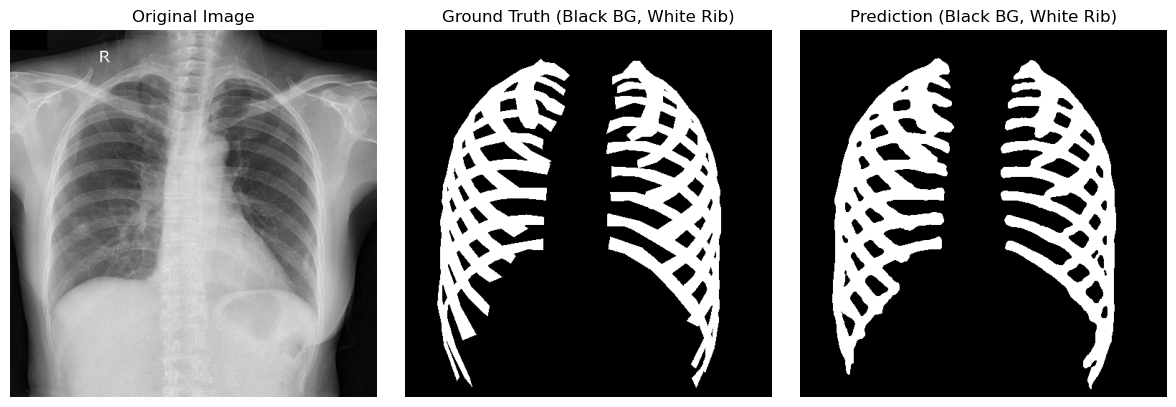

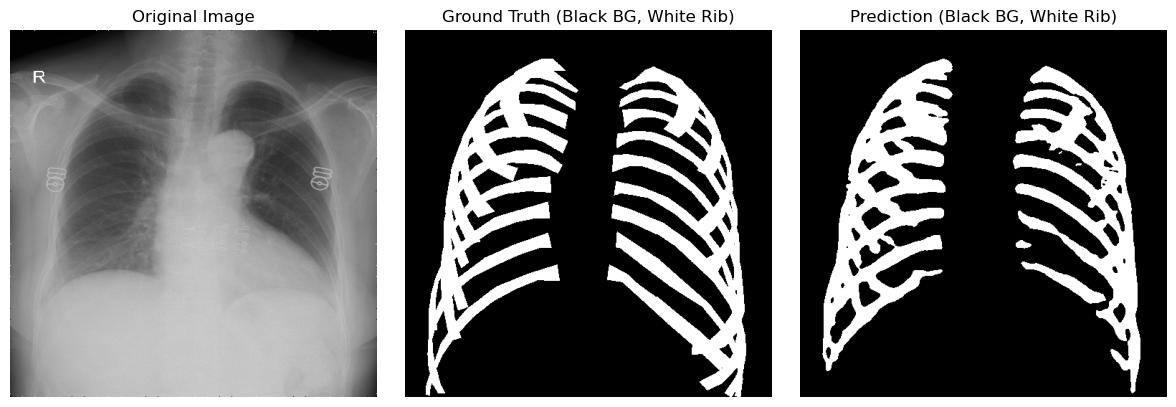

In [75]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# GPU設備
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("使用 GPU (MPS) 進行推論")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("使用GPU (CUDA) 進行推論")
else:
    device = torch.device("cpu")
    print("使用 CPU 進行推論")

# 設定模型為評估模式
model.to(device)
model.eval()  

# 顯示前 5 筆資料進行推論
for idx, (img_raw, img_norm, gt_mask) in enumerate(test_dataloader):
    if idx >= 5:  # 顯示前 5 筆資料
        break

    # 模型推論
    img_norm = img_norm.to(device)  
    
    # 禁用梯度計算，減少記憶體消耗並加速推理過程
    with torch.no_grad():
        logits = model(img_norm)  # 模型預測，輸出形狀 (1, C, H, W)，C 是類別數，H 和 W 是影像尺寸
        pr_mask = torch.argmax(logits, dim=1).squeeze(0)  # 取得每個像素點的預測類別 (H, W)

    # 創建圖形
    plt.figure(figsize=(12, 4))

    # -------- 顯示原圖 --------
    plt.subplot(1, 3, 1)  
    img_np = img_raw.squeeze()  # 去除多餘的維度
    if isinstance(img_np, torch.Tensor):  # 檢查是否為 Tensor
        img_np = img_np.cpu().numpy()  # 影像移回 CPU 並轉為 Numpy 陣列
    plt.imshow(img_np, cmap='gray')  # 顯示原始影像
    plt.title("Original Image")  
    plt.axis("off")  

    # -------- 顯示 Ground Truth Mask --------
    gt_tensor = gt_mask.squeeze()  # 去除多餘的維度，確保遮罩的形狀為 (H, W)
    if gt_tensor.ndim == 3:  # 若是三維（C, H, W），則取最大類別作為遮罩
        gt_tensor = torch.argmax(gt_tensor, dim=0)
    gt_np = gt_tensor.cpu().numpy() 
    gt_np = 1 - gt_np  # 將肋骨部分反轉為白色，背景反轉為黑色
    plt.subplot(1, 3, 2)  
    plt.imshow(gt_np, cmap='gray')  # 顯示 Ground Truth 遮罩
    plt.title("Ground Truth (Black BG, White Rib)")  
    plt.axis("off")  

    # -------- 顯示 Prediction Mask --------
    pr_np = pr_mask.cpu().numpy()  
    pr_np = 1 - pr_np  # 反轉預測遮罩，將背景反轉為黑色，肋骨為白色
    plt.subplot(1, 3, 3) 
    plt.imshow(pr_np, cmap='gray')  # 顯示預測遮罩
    plt.title("Prediction (Black BG, White Rib)") 
    plt.axis("off") 

    plt.tight_layout()  
    plt.show()



In [76]:
# 評估模型在測試集上的表現
test_epoch = smp.utils.train.ValidEpoch(
    model=model,               # 使用已訓練好的模型
    loss=loss,                 # 損失函數
    metrics=metrics,           # 評估指標
    device=DEVICE,             # 使用的設備
)

# 創建測試資料集和資料前處理
test_dataset = Dataset(
    x_test_dir,                                 # 測試集影像資料夾
    y_test_dir,                                 # 測試集遮罩資料夾
    preprocessing=get_preprocessing(preprocessing_fn),  # 資料前處理方法
    classes=CLASSES,                            # 類別名稱
)

# 創建 DataLoader加載測試資料集
test_dataloader = DataLoader(test_dataset, 
                              batch_size=1,          # 設定批次大小為 1
                              shuffle=False,         # 不隨機打亂
                              num_workers=0)      

# 執行測試，並獲取損失和評估指標
logs = test_epoch.run(test_dataloader) 


成功過濾！目前資料集共有 49 張影像。
valid: 100%|█| 49/49 [00:07<00:00,  6.22it/s, dice_loss - 0.05589, iou_score - 0


In [86]:
print(f"測試集平均 Dice Loss: {logs['dice_loss']:.4f}")
print(f"測試集平均 IoU Score: {logs['iou_score']:.4f}")

測試集平均 Dice Loss: 0.0559
測試集平均 IoU Score: 0.8968


In [77]:
# 創建測試資料集，並應用資料前處理方法
# 加載測試影像和遮罩資料，並應用前處理方法（如標準化等）
test_dataset = Dataset(
    x_test_dir,  
    y_test_dir,  
    preprocessing=get_preprocessing(preprocessing_fn),  
    classes=CLASSES, 
)

# 創建另一個測試資料集版本，用於顯示資料
# 只包含影像和遮罩的路徑，不進行任何前處理
test_dataset_vis = Dataset(
    x_test_dir, 
    y_test_dir, 
    classes=CLASSES 
)

成功過濾！目前資料集共有 49 張影像。
成功過濾！目前資料集共有 49 張影像。


In [78]:
import os

# 設定存放預測結果的資料夾路徑
path = './result/prediction/rib_seg_reult'

# 檢查資料夾是否存在
if not os.path.exists(path):  # 檢查資料夾是否已經存在
    os.makedirs(path)  # 不在，則創建資料夾


In [79]:
# 迭代測試資料集中的每一個樣本
for i in range(len(test_dataset_vis)):
    # 獲取遮罩檔案的檔名
    name = os.path.basename(test_dataset_vis.masks_fps[i])

    # 從資料集獲取影像和真實的遮罩
    image, gt_mask = test_dataset[i]  
    # 模型推論
    x_tensor = torch.from_numpy(image).to(device).unsqueeze(0) 
    pr_mask = model.predict(x_tensor)  # 輸出的形狀為 (1, 2, H, W)
    pr_mask = pr_mask.squeeze().cpu().numpy()  # 去除批次維度

    # 將 one-hot 編碼的遮罩轉換為類別圖（0=背景, 1=肋骨）
    pr_mask_index = np.argmax(pr_mask, axis=0).astype(np.uint8) 

    # 反轉遮罩，讓肋骨為白色，背景為黑色
    pr_mask_index = 1 - pr_mask_index  # 將 0 和 1 反轉

    # 儲存預測的黑白圖
    save_path = os.path.join(path, name.replace('.jpg', '.png'))  # 更改檔案名稱，將 .jpg 改為 .png
    plt.imsave(save_path, pr_mask_index, cmap='gray')  # 使用 `imsave` 儲存影像，`cmap='gray'` 是指灰階顯示

    print(f"Saved: {save_path}")



Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_000.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_001.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_002.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_003.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_004.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_005.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_006.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_007.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_008.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_009.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_010.png
Saved: ./result/prediction/rib_seg__0416_313112019(3)/VinDr_RibCXR_val_011.png
Saved: ./result/prediction/rib_seg__0416_313112019(3

[SKIP] Missing: .ipynb_checkpoints
[BAD] VinDr_RibCXR_val_004.png - Dice: 0.7853, IoU: 0.6465


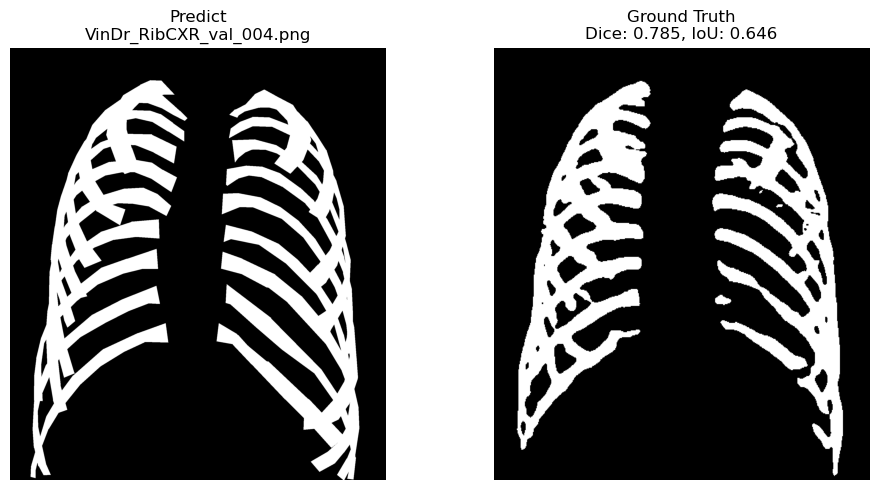

[BAD] VinDr_RibCXR_val_010.png - Dice: 0.8124, IoU: 0.6840


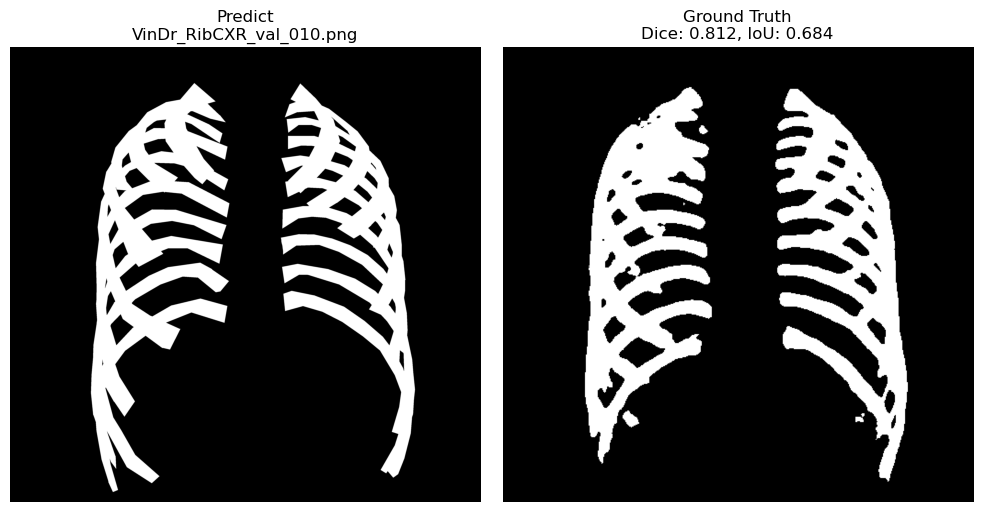

總共顯示 2 張不合格的 segmentation 結果


In [80]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 計算 Dice 系數，衡量預測與真實遮罩的重疊程度
def dice_coefficient(pred, gt):
    intersection = np.sum(pred * gt)  # 計算預測與真實遮罩的交集
    return (2. * intersection) / (np.sum(pred) + np.sum(gt) + 1e-7)  # 計算 Dice

# 計算 IoU 衡量預測與真實遮罩的重疊程度
def iou_score(pred, gt):
    intersection = np.sum(pred * gt)  # 計算交集
    union = np.sum(pred) + np.sum(gt) - intersection  # 計算聯集
    return intersection / (union + 1e-7)  # 計算 IoU

# 顯示失敗的預測案例
def show_failed_case(pred_img, gt_img, dice, iou, filename):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))  
    axs[0].imshow(pred_img, cmap='gray')  # 顯示預測結果
    axs[0].set_title(f'Predict\n{filename}')  
    axs[1].imshow(gt_img, cmap='gray')  # 真實遮罩
    axs[1].set_title(f'Ground Truth\nDice: {dice:.3f}, IoU: {iou:.3f}')  # 標題，包含 Dice 和 IoU 分數
    for ax in axs: ax.axis('off')  
    plt.tight_layout()  
    plt.show()  

# 預測和真實遮罩資料夾路徑
predict_folder = 'rib_dataset/test/mask'
gt_folder = './result/prediction/rib_seg_reult'

# 設定 Dice 和 IoU 的閾值 定義不合格樣本
dice_threshold = 0.7  
iou_threshold = 0.7   

count = 0  # 記錄不合格案例的數量
# 迭代預測資料夾中的每一個檔案
for filename in os.listdir(predict_folder):
    pred_path = os.path.join(predict_folder, filename)  # 預測遮罩的路徑
    gt_path = os.path.join(gt_folder, filename)  # 真實遮罩的路徑
    
    if not os.path.exists(gt_path):  # 檢查是否有對應的真實遮罩
        print(f"[SKIP] Missing: {filename}") 
        continue

    # 讀取預測遮罩和真實遮罩
    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

    # 如果預測和真實遮罩的尺寸不同，則調整真實遮罩的尺寸使其與預測遮罩一致
    if pred_mask.shape != gt_mask.shape:
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 將遮罩二值化
    pred_bin = (pred_mask > 127).astype(np.uint8)
    gt_bin = (gt_mask > 127).astype(np.uint8)

    # 計算 Dice 系數和 IoU 分數
    dice = dice_coefficient(pred_bin, gt_bin)
    iou = iou_score(pred_bin, gt_bin)

    # 如果 Dice 或 IoU 低於設定的閾值，則顯示失敗案例
    if dice < dice_threshold or iou < iou_threshold:
        print(f"[BAD] {filename} - Dice: {dice:.4f}, IoU: {iou:.4f}")
        # 顯示失敗案例：預測圖、真實圖、Dice 和 IoU 分數
        show_failed_case(pred_mask, gt_mask, dice, iou, filename)
        count += 1  # 不合格案例計數

print(f"總共顯示 {count} 張不合格的 segmentation 結果")


In [81]:
# 準備三個空清單，用來存放所有測試樣本
dice_list, iou_list, filenames = [], [], []

for filename in os.listdir(predict_folder):
    pred_path = os.path.join(predict_folder, filename)
    gt_path = os.path.join(gt_folder, filename)

    if not os.path.exists(gt_path):
        continue
    # 讀取黑白遮罩圖
    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    # 如果預測圖跟答案圖的解析度不一樣，強制將答案圖縮放到與預測圖一致
    if pred_mask.shape != gt_mask.shape:
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
    # 將 0-255 的灰階圖轉為 0 與 1 的二進位矩陣
    pred_bin = (pred_mask > 127).astype(np.uint8)
    gt_bin = (gt_mask > 127).astype(np.uint8)
    # 計算圖片 Dice 與 IoU
    dice = dice_coefficient(pred_bin, gt_bin)
    iou = iou_score(pred_bin, gt_bin)

    dice_list.append(dice)
    iou_list.append(iou)
    filenames.append(filename)



[BAD] VinDr_RibCXR_val_004.png - Dice=0.7853, IoU=0.6465


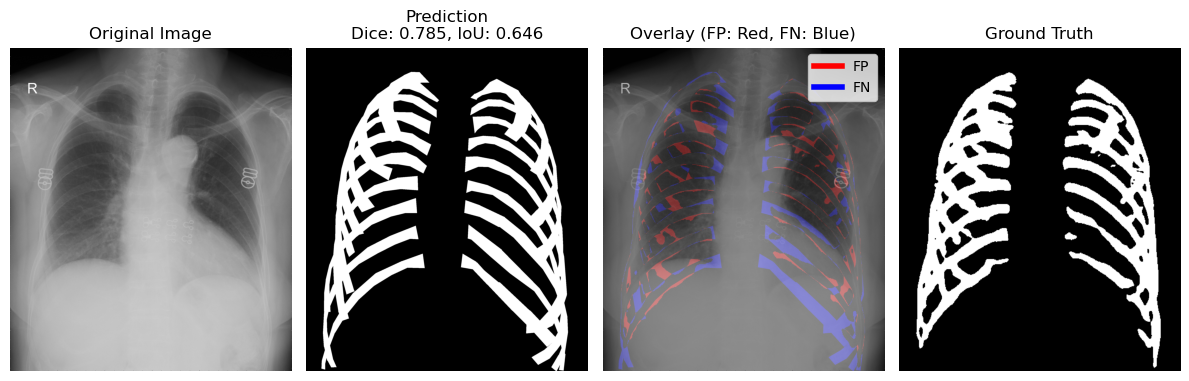

[BAD] VinDr_RibCXR_val_010.png - Dice=0.8124, IoU=0.6840


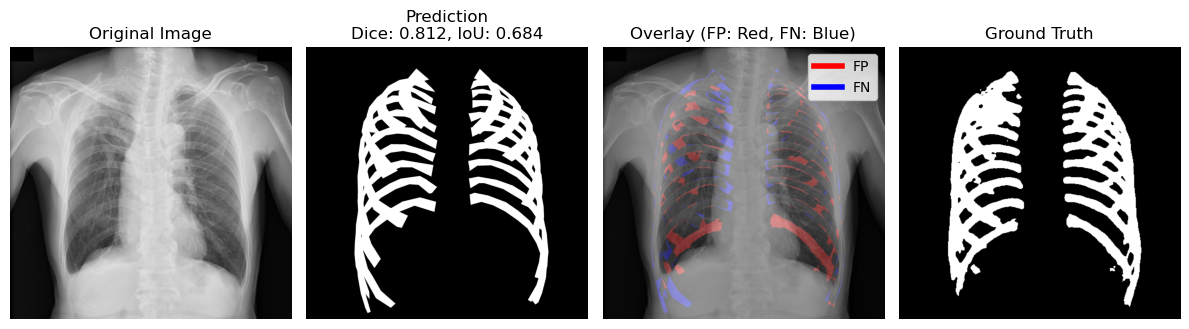


📋 錯誤統整：
[BAD] VinDr_RibCXR_val_004.png - Dice=0.7853, IoU=0.6465
[BAD] VinDr_RibCXR_val_010.png - Dice=0.8124, IoU=0.6840


In [85]:
import matplotlib.pyplot as plt

# 計算 Dice 和 IoU
def dice_coefficient(pred, gt):
    intersection = np.sum(pred * gt)
    return (2. * intersection) / (np.sum(pred) + np.sum(gt) + 1e-7)

def iou_score(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt) - intersection
    return intersection / (union + 1e-7)

# 資料夾路徑
predict_folder = 'rib_dataset/test/mask'
gt_folder = './result/prediction/rib_seg_reult'
img_folder = 'rib_dataset/test/img'

# 閾值
dice_threshold = 0.7
iou_threshold = 0.7

bad_cases = []

for filename in os.listdir(predict_folder):
    if not filename.endswith('.png'):
        continue

    pred_path = os.path.join(predict_folder, filename)
    gt_path = os.path.join(gt_folder, filename)
    img_path = os.path.join(img_folder, filename)

    if not os.path.exists(gt_path):
        print(f"[SKIP] GT 不存在: {filename}")
        continue

    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    img_raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if pred_mask is None or gt_mask is None or img_raw is None:
        print(f"[ERROR] 無法讀取某檔案: {filename}")
        continue

    if pred_mask.shape != gt_mask.shape:
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
    if img_raw.shape != gt_mask.shape:
        img_raw = cv2.resize(img_raw, (gt_mask.shape[1], gt_mask.shape[0]), interpolation=cv2.INTER_AREA)

    pred_bin = (pred_mask > 127).astype(np.uint8)
    gt_bin = (gt_mask > 127).astype(np.uint8)

    dice = dice_coefficient(pred_bin, gt_bin)
    iou = iou_score(pred_bin, gt_bin)

    if dice < dice_threshold or iou < iou_threshold:
        msg = f"[BAD] {filename} - Dice={dice:.4f}, IoU={iou:.4f}"
        print(msg)
        bad_cases.append(msg)

        # 計算錯誤區域
        fp = np.logical_and(pred_bin == 1, gt_bin == 0)
        fn = np.logical_and(pred_bin == 0, gt_bin == 1)

        error_vis = np.zeros((*gt_bin.shape, 3), dtype=np.uint8)
        error_vis[fp] = [255, 0, 0]  # 紅色表示假陽性
        error_vis[fn] = [0, 0, 255]  # 藍色表示假陰性

        # 疊圖顯示
        overlay = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2BGR)
        overlay = cv2.addWeighted(overlay, 0.7, error_vis, 0.3, 0)

        # 顯示圖片
        plt.figure(figsize=(12, 4))

        # 顯示原圖
        plt.subplot(1, 4, 1)
        img_np = img_raw.squeeze()
        if isinstance(img_np, torch.Tensor):
            img_np = img_np.cpu().numpy()
        plt.imshow(img_np, cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        # 顯示預測圖（選擇通道）
        plt.subplot(1, 4, 2)
        pr_mask_np = pred_mask.squeeze()  # 使用預測圖的第一個通道
        plt.imshow(pr_mask_np, cmap='gray')
        plt.title(f"Prediction\nDice: {dice:.3f}, IoU: {iou:.3f}")
        plt.axis("off")

        # 顯示 Ground Truth 遮罩
        plt.subplot(1, 4, 4)
        gt_np = gt_bin.squeeze()
        plt.imshow(gt_np, cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        
        # 顯示錯誤區域（紅色和藍色區域）
        plt.subplot(1, 4, 3)
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title("Overlay (FP: Red, FN: Blue)")
        plt.axis("off")

        # 添加顏色圖例
        handles = [plt.Line2D([0], [0], color='red', lw=4, label='FP'),
                   plt.Line2D([0], [0], color='blue', lw=4, label='FN')]
        plt.legend(handles=handles, loc='upper right')

        plt.tight_layout()
        plt.show()

# 顯示所有錯誤的案例
print("\n📋 錯誤統整：")
for case in bad_cases:
    print(case)



錯誤區域標註：

紅色區域表示假陽性（False Positive, FP），也就是模型錯誤地預測為肋骨區域，但實際上是背景。

藍色區域表示假陰性（False Negative, FN），即模型錯誤地預測為背景區域，但實際上是肋骨。
